---
title: "Non-linear State Space time-series model with neural network dynamics"
---

In [1]:
#julia 1.10.0-rc2

In [2]:
using CSV, DataFrames, Flux, Plots, StatsPlots, Random, Statistics, LinearAlgebra, Distributions, ForwardDiff

In [3]:
dates = (CSV.File("../data/AirPassengers.csv") |> DataFrame)[!,1]
Y = Float32.((CSV.File("../data/AirPassengers.csv") |> DataFrame)[!,2])

Y_train = Y[1:end-36]
Y_test = Y[end-35:end]

dates_train = dates[1:end-36]
dates_test = dates[end-35:end]

Yl = sqrt.(Y_train)
Yd = diff(Yl)
Ydd = Yd[12:end].-Yd[1:end-11]

Ydm = mean(Ydd)
Yds = std(Ydd)

Ydst = (Ydd.-Ydm)./Yds

96-element Vector{Float32}:
 -0.4350851
 -0.13233775
  0.8018298
  0.10237843
 -1.0938587
  0.4913828
  0.85459936
  0.51611435
  0.2902387
 -0.34002298
 -1.5709839
  1.3312525
 -0.30409646
  ⋮
  0.4756324
 -1.6120677
  1.6790314
 -0.36825964
 -1.3643352
  0.7370608
  1.2538595
  1.3677956
 -0.17014956
 -0.458069
 -2.2662938
  0.62650794

## Quick model summary
State space model with linear observations and non-linear state-transition, modelled by a feedforward Network:

$$\mathbf{y}_t=\mathbf{Z}\mathbf{x}_t+\epsilon_t,\quad \epsilon\sim\mathcal{N}(\mathbf{0},\mathbf{H})$$
$$\mathbf{x}_t=T_\theta(\mathbf{x}_{t-1})+R\eta,\quad \eta\sim\mathcal{N}(\mathbf{0},\mathbf{Q})$$

where $\mathbf{T}_\theta$ denotes the feedforward network with parameter vector $\theta$.

=> We can apply the [extended Kalman-Filter](https://en.wikipedia.org/wiki/Extended_Kalman_filter) and derive the likelihood
function from there.

The challenging part is that we need the Jacobian of $T_\theta$ with respect to the network inputs to apply the extended Kalman filter. Furthermore, we need to differentiate through the Jacobian, i.e. apply autodiff twice. With `ForwardDiff.jl`, this is pretty neat to implement.

In [4]:
struct NeuralStateSpaceModel
    Z #linear observations
    Hl
    
    Tnet #non-linear state-transitions
    R
    Ql
end
Flux.@functor NeuralStateSpaceModel


function kalman_filter(m::NeuralStateSpaceModel, y, a_t, P_t)
    y_t = y[1]
    
    Z = m.Z
    H = transpose(m.Hl)*m.Hl
    
    Tnet = m.Tnet
    R = m.R
    Q = transpose(m.Ql)*m.Ql
    
    
    m_t = Z*a_t
  
    F_t = Z*P_t*transpose(Z) .+ H 
    
    a_tt = a_t .+ P_t*transpose(Z)*inv(F_t)*(y_t .- m_t)
    
    P_tt = P_t .- P_t*transpose(Z)*inv(F_t)*Z*P_t
    
    a_tp1 = Tnet(a_tt)
    T = ForwardDiff.jacobian(x->Tnet(x), a_tt)
    
    P_tp1 = T*P_tt*transpose(T).+R*Q*transpose(R)
    

    dist_t = MvNormal(m_t[:],F_t)
    
    if length(y)>1
        dist_tp1, a_tp2, P_tp2 = kalman_filter(m,y[2:end],a_tp1,P_tp1)
        return vcat(dist_t,dist_tp1), hcat(a_tp1,a_tp2), vcat([P_tp1],P_tp2)
    else
        return dist_t, a_tp1, [P_tp1]
    end
end


struct NetSpaceModel
    Z
    Hl
    
    Tnet
    R
    Ql
    
    a_0
    P_0l
end
Flux.@functor NetSpaceModel

function NetSpaceModel(n_latent, n_obs)
    Z = randn(n_obs, n_latent)
    Hl = randn(n_obs, n_obs).*0.1
    
    Tnet = Chain(Dense(n_latent, n_latent, relu), Dense(n_latent,n_latent))
    R = randn(n_latent,n_latent) .*0.1
    Ql = randn(n_latent, n_latent).*0.1 
    
    a_0 = randn(n_latent)
    P_0l = randn(n_latent, n_latent)
    
    return NetSpaceModel(Z, Hl, Tnet, R, Ql, a_0, P_0l)
end


function to_state_space(m::NetSpaceModel)
    return NeuralStateSpaceModel(m.Z,m.Hl,m.Tnet,m.R,m.Ql)
end


function kalman_filter(m::NetSpaceModel, y)
    ys = Flux.unstack(y,1)
    sp = to_state_space(m)
    
    a_0 = m.a_0
    P_0 = transpose(m.P_0l)*m.P_0l
    
    return kalman_filter(sp,ys,a_0,P_0)
end


function llikelihood(m::NetSpaceModel, y)
    dists, _, _ = kalman_filter(m,y)
        
    return mean(map(i->logpdf(dists[i],[y[i]]),1:length(y)))
end



llikelihood (generic function with 1 method)

In [5]:
Random.seed!(321)
m = NetSpaceModel(2,1)
ps,f = Flux.destructure(m)

([1.0536472842708524, -0.1650645561495271, -0.1812842851043093, 0.9319831728935242, -0.6539088487625122, 0.9382558465003967, 0.9103027582168579, 0.0, 0.0, -0.17880913615226746  …  -0.0842870017796073, -0.02841002036041786, -0.02829153888679626, -0.22301231389505347, 0.448863112774162, -0.6465478786013305, 0.22263517787734172, 1.1695678158848581, 1.128705127014328, -0.21111803080879846], Restructure(NetSpaceModel, ..., 29))

In [6]:
opt = ADAM(0.001)

Adam(0.001, (0.9, 0.999), 1.0e-8, IdDict{Any, Any}())

In [7]:
for i in 1:2500    
    grads = ForwardDiff.gradient(x -> -llikelihood(f(vcat(x)),Ydst), ps)

    
    Flux.Optimise.update!(opt, ps, grads)
    if i%250==0
        println(-llikelihood(f(ps),Ydst))
    end
end

┌ Warning: Layer with Float32 parameters got Float64 input.
│   The input will be converted, but any earlier layers may be very slow.
│   layer = Dense(2 => 2, relu)  # 6 parameters
│   summary(x) = "2-element Vector{Float64}"
└ @ Flux ~/.julia/packages/Flux/jgpVj/src/layers/stateless.jl:60


1.8231251169493834
1.4324884716741206
1.4025903440827354
1.3899193022997833
1.3600015357332707
1.3251548919519776


LoadError: InterruptException:

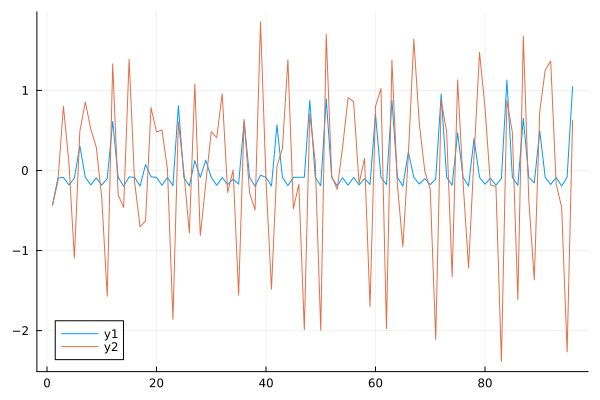

In [8]:
m_star = f(ps)
plot(map(x->x.μ[1],kalman_filter(m_star, Ydst)[1]))
plot!(Ydst)

In [9]:
transformer = vcat(
hcat(Diagonal(ones(12)),Diagonal(zeros(12)),Diagonal(zeros(12))),
hcat(Diagonal(ones(12)),Diagonal(ones(12)),Diagonal(zeros(12))),
hcat(Diagonal(ones(12)),Diagonal(ones(12)),Diagonal(ones(12)))
);

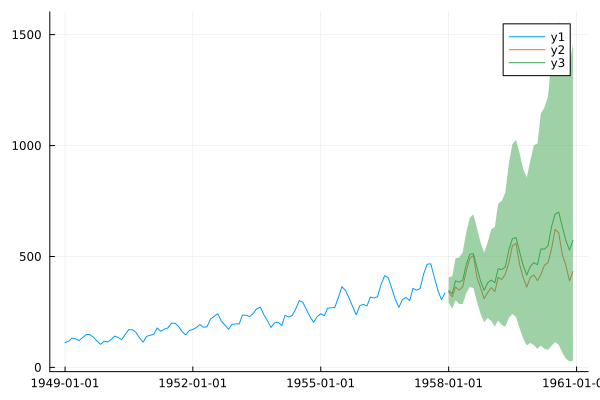

In [10]:
a_T = kalman_filter(m_star, Ydst)[2][:,end]
P_T = kalman_filter(m_star, Ydst)[3][end]


R = m_star.R
Q = Hermitian(transpose(m_star.Ql)*m_star.Ql)
H = Hermitian(transpose(m_star.Hl)*m_star.Hl)

m = size(Q,1)

preds = []

for i in 1:5000
    
    Ls = [rand(MvNormal(a_T, Hermitian(P_T)))]
    ys = []

    for t in 1:36
        L_t1 = m_star.Tnet(Ls[end]) .+ R*rand(MvNormal(zeros(m), Q))
        push!(Ls,L_t1)

        y_tp1 = m_star.Z*L_t1 .+ rand(MvNormal(zeros(1), H))
        push!(ys, y_tp1[1])
    end
    push!(preds, (cumsum(transformer*(ys.*Yds .+ Ydm).+ repeat(Yd[end-11:end],3)).+Yl[end]).^2)
end

preds = hcat(preds...)

means = mean(preds,dims=2)[:]
lower = mapslices(x->quantile(x,0.05),preds,dims=2)
upper = mapslices(x->quantile(x,0.95),preds,dims=2)

plot(dates_train, Y_train)
plot!(dates_test, Y_test)
plot!(dates_test,means, ribbon = (means.-lower, upper.-means))

In [11]:
sqrt(mean((means.-Y_test).^2))

66.33436769424183

=> Compare this to the results [here](https://www.sarem-seitz.com/posts/winning-with-simple-not-even-linear-time-series-models.html#:~:text=set%20to%201-,RMSE,-Simple). Obviously, given the small dataset, this performance is not as stable for different seeds. Needs larger datasets to fully take advantage of the flexibility of the Neural Network.